# 10. Make two-part linear model

1. Make your own example that calls for a two-part linear model:
   - a. Invent plausible story
   - b. Make fake data
   - c. Apply a model

2. Check how the model behaves when in the data:
   - a. The difference between the two parts becomes less pronounced
   - b. Noise increases
   - c. The switch occurs more gradually

In [34]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az
from scipy import stats

np.random.seed(42)

## Students Productivity

A teacher is tracking students productivity during the lectures with a small test-suprises. They measure during 10 hour day.
- Coffe production
- How many inteligent words/calculations they used

They suspect that around 5th hour coffe started giving doppio instead of espresso which increased the cognitive abilities of the students.

## Make fake data

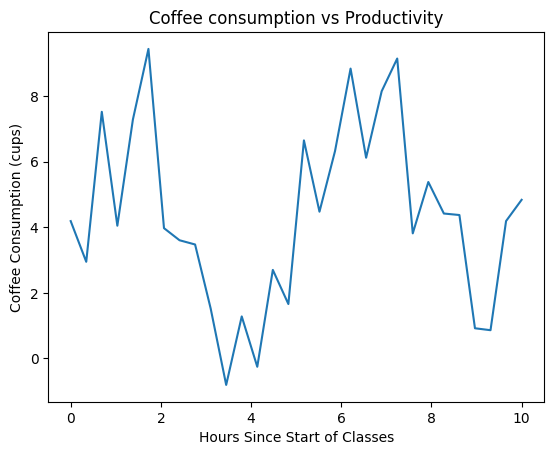

In [39]:
n_points = 30
X = np.linspace(0, 10, n_points)
coffee_trend = 3 + 0.3 * X
Y = coffee_trend + 3 * np.sin(1.2 * X) + np.random.normal(0, 1.5, n_points)

plt.plot(X, Y)
plt.xlabel("Hours Since Start of Classes")
plt.ylabel("Coffee Consumption (cups)")
plt.title("Coffee consumption vs Productivity")
plt.show()

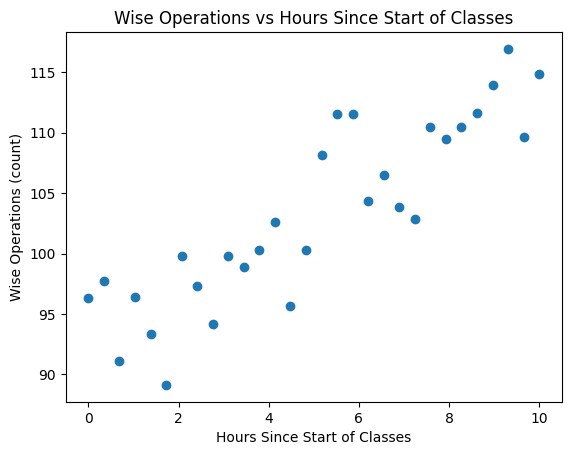

In [40]:
X_wise = np.copy(X)
mask_before = X_wise < 5.0
Y_wise = np.where(mask_before,
                  -Y + 100,
                  (-Y + 100) * 1.15)

Y_wise += np.random.normal(0, 2, n_points)

plt.scatter(X_wise, Y_wise)
plt.xlabel("Hours Since Start of Classes")
plt.ylabel("Wise Operations (count)")
plt.title("Wise Operations vs Hours Since Start of Classes")
plt.show()

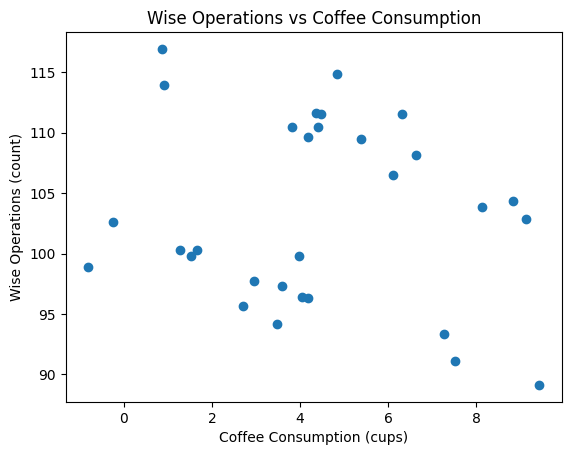

In [41]:
plt.scatter(Y, Y_wise)
plt.xlabel("Coffee Consumption (cups)")
plt.ylabel("Wise Operations (count)")
plt.title("Wise Operations vs Coffee Consumption")
plt.show()

In [42]:
with pm.Model() as model:

    # Change point in X-space
    tau = pm.Uniform("tau", lower=X_wise.min(), upper=X_wise.max())

    b_1 = pm.Uniform("b_1", lower=0.5, upper=1.5)
    b_2 = pm.Uniform("b_2", lower=1.0, upper=1.5)

    base_signal = 100 - Y

    m_wise = pm.Deterministic(
        "m_wise",
        pm.math.switch(
            X_wise < tau,
            b_1 * base_signal,
            b_2 * base_signal
        )
    )

    sigma_wise = pm.Uniform("sigma_wise", lower=0.1, upper=10)

    wise_ops = pm.Normal(
        "wise_ops",
        mu=m_wise,
        sigma=sigma_wise,
        observed=Y_wise
    )

    idata = pm.sample(800, tune=800, chains=1, return_inferencedata=True)


Output()

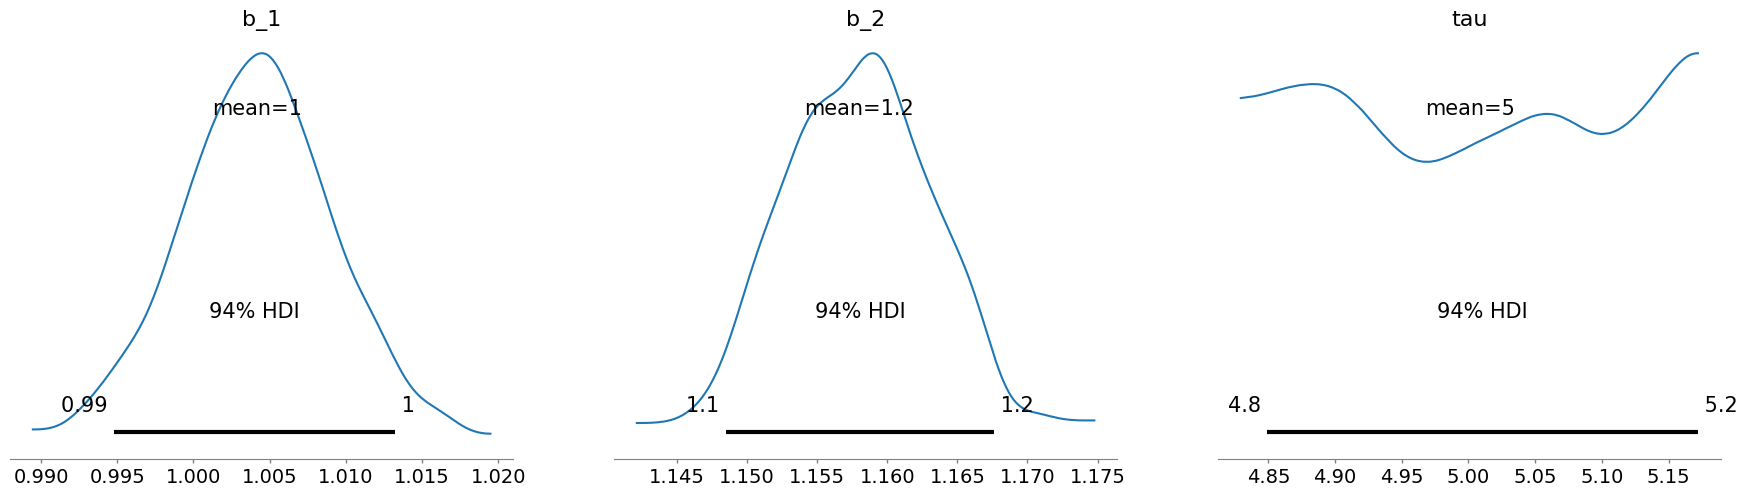

In [43]:
with model:
    az.plot_posterior(
    idata,
    var_names=["b_1", "b_2", "tau"],
    point_estimate="mean",
)


As we can see, model predicted both slopes and the chaning poing with good certenity.

## 2a. Less Pronounced Difference Between Parts


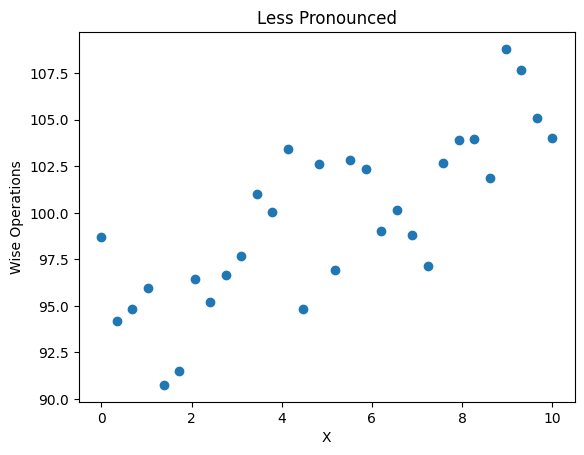

In [53]:
base_signal = 100 - Y
factor_before = 1.0
factor_after = 1.08

Y_wise_a = np.where(
    X < 5.0,
    factor_before * base_signal,
    factor_after * base_signal
)

Y_wise_a += np.random.normal(0, 2, n_points)

plt.scatter(X, Y_wise_a)
plt.title("Less Pronounced")
plt.xlabel("X")
plt.ylabel("Wise Operations")
plt.show()

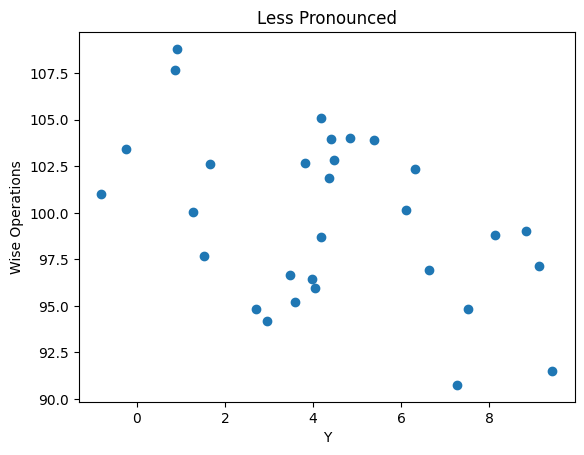

In [54]:
plt.scatter(Y, Y_wise_a)
plt.title("Less Pronounced")
plt.xlabel("Y")
plt.ylabel("Wise Operations")
plt.show()

In [55]:
with pm.Model() as model:

    # Change point in X-space
    tau = pm.Uniform("tau", lower=X_wise.min(), upper=X_wise.max())

    b_1 = pm.Uniform("b_1", lower=0.5, upper=1.5)
    b_2 = pm.Uniform("b_2", lower=1.0, upper=1.5)

    base_signal = 100 - Y

    m_wise = pm.Deterministic(
        "m_wise",
        pm.math.switch(
            X_wise < tau,
            b_1 * base_signal,
            b_2 * base_signal
        )
    )

    sigma_wise = pm.Uniform("sigma_wise", lower=0.1, upper=10)

    wise_ops = pm.Normal(
        "wise_ops",
        mu=m_wise,
        sigma=sigma_wise,
        observed=Y_wise_a
    )

    idata = pm.sample(800, tune=800, chains=1, return_inferencedata=True)


Output()

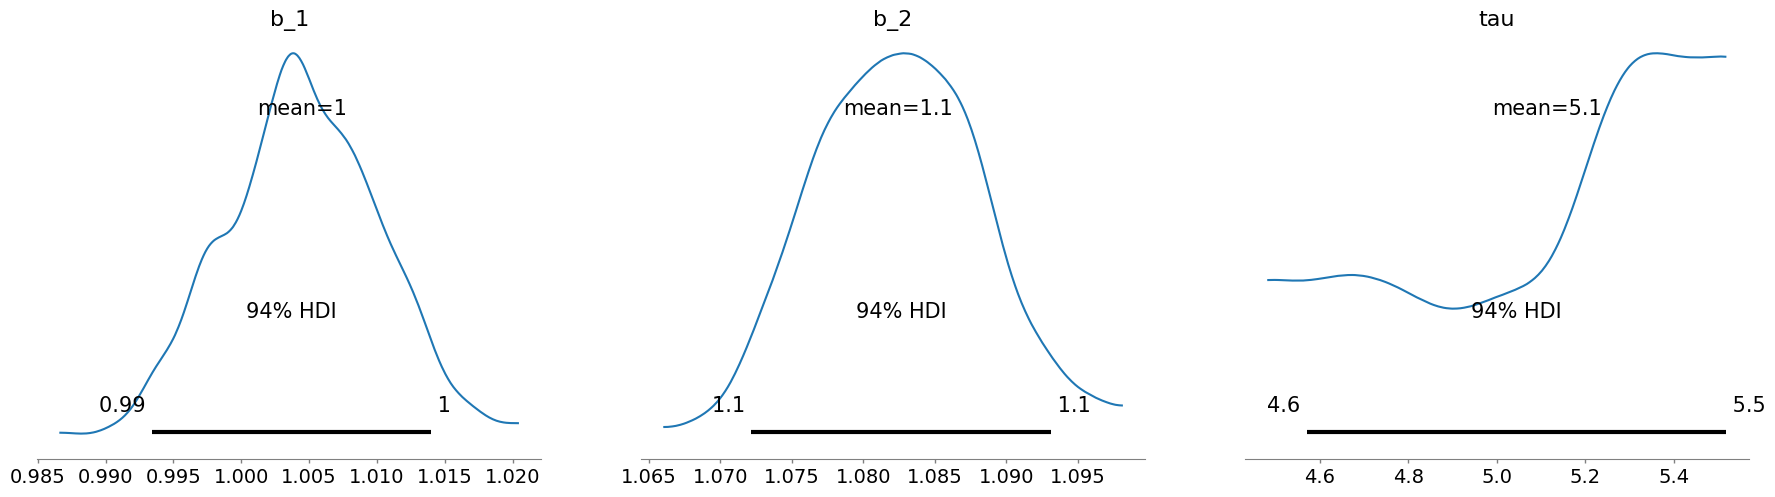

In [56]:
with model:
    az.plot_posterior(
    idata,
    var_names=["b_1", "b_2", "tau"],
    point_estimate="mean",
)


With less pronaunced data, we can see that mean varies from 4.5 to 5.5 without any centain peak. This is expected, because switch point was much harder to decect and not that clearly visibile.

## 2b. Increased Noise

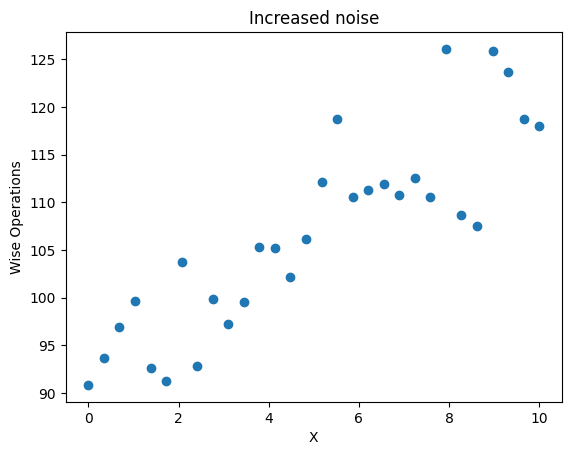

In [57]:
noise_sigma = 6.0  # larger noise

Y_wise_b = np.where(
    X < 5.0,
    1.0 * base_signal,
    1.2 * base_signal
)

Y_wise_b += np.random.normal(0, noise_sigma, n_points)

plt.scatter(X, Y_wise_b)
plt.title("Increased noise")
plt.xlabel("X")
plt.ylabel("Wise Operations")
plt.show()

In [58]:
with pm.Model() as model:

    # Change point in X-space
    tau = pm.Uniform("tau", lower=X_wise.min(), upper=X_wise.max())

    b_1 = pm.Uniform("b_1", lower=0.5, upper=1.5)
    b_2 = pm.Uniform("b_2", lower=1.0, upper=1.5)

    base_signal = 100 - Y

    m_wise = pm.Deterministic(
        "m_wise",
        pm.math.switch(
            X_wise < tau,
            b_1 * base_signal,
            b_2 * base_signal
        )
    )

    sigma_wise = pm.Uniform("sigma_wise", lower=0.1, upper=10)

    wise_ops = pm.Normal(
        "wise_ops",
        mu=m_wise,
        sigma=sigma_wise,
        observed=Y_wise_b
    )

    idata = pm.sample(800, tune=800, chains=1, return_inferencedata=True)


Output()

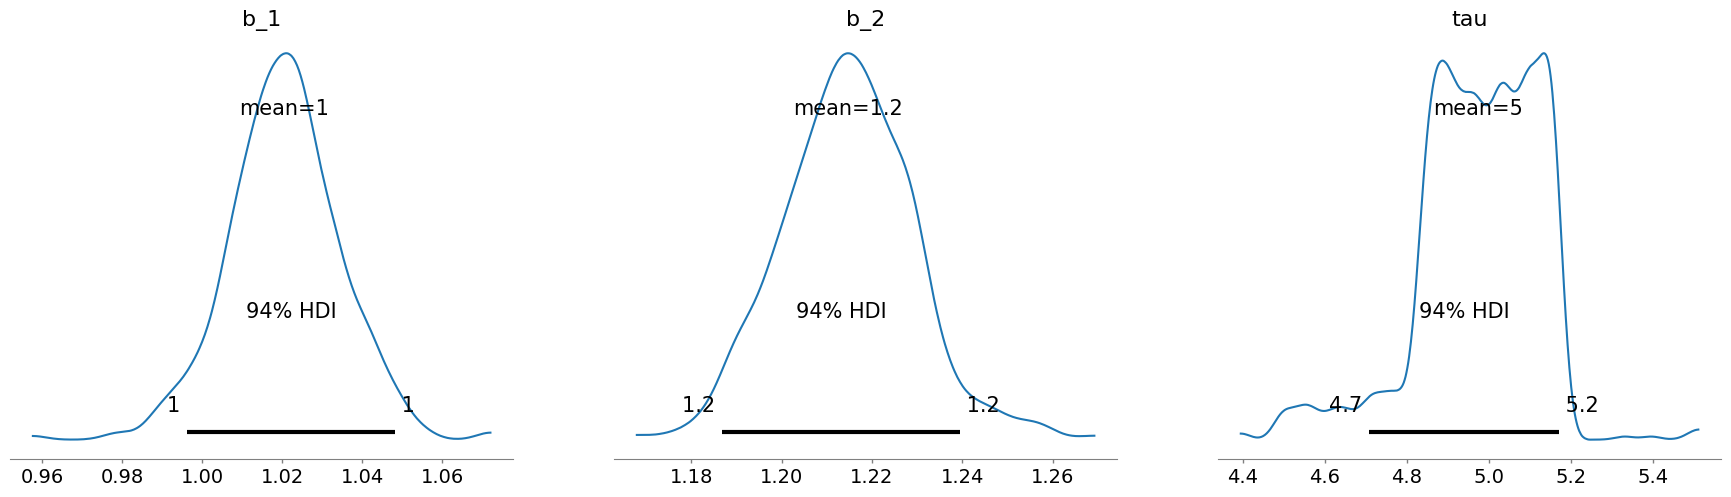

In [59]:
with model:
    az.plot_posterior(
    idata,
    var_names=["b_1", "b_2", "tau"],
    point_estimate="mean",
)

With noised data, certenty of the slopes of data is wider, due to bigger noise model is not sure on what slope the data was generated. Its harder to calculate the trend with more noised data. However the mean is calculated properly, because switch point is still visible.

## 2c. Gradual Switch

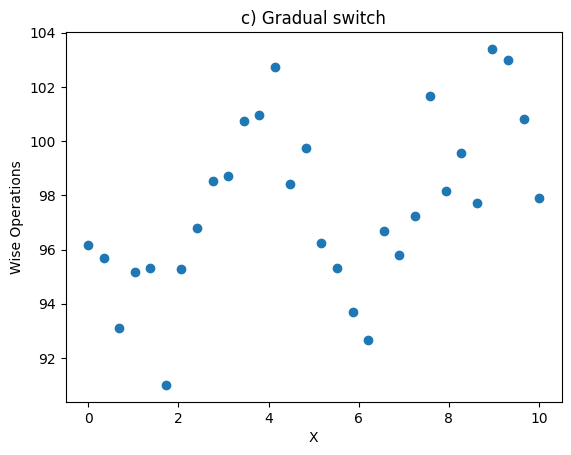

In [60]:
k = 0.5  # smaller = more gradual transition
w = 1 / (1 + np.exp(-k * (X - 5.0)))

Y_wise_c = (1 - w) * 1.0 * base_signal + w * 1.05 * base_signal
Y_wise_c += np.random.normal(0, 2, n_points)

plt.scatter(X, Y_wise_c)
plt.title("c) Gradual switch")
plt.xlabel("X")
plt.ylabel("Wise Operations")
plt.show()


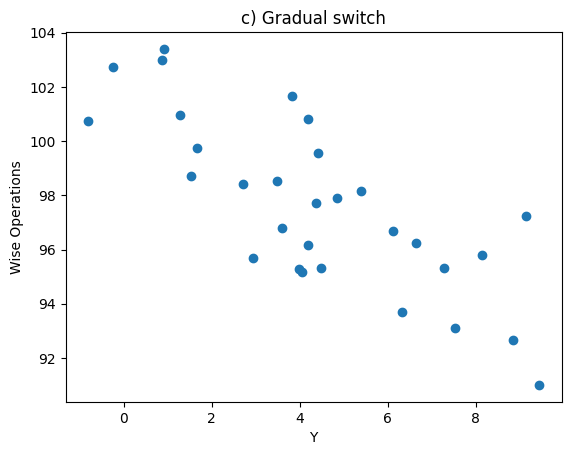

In [61]:
plt.scatter(Y, Y_wise_c)
plt.title("c) Gradual switch")
plt.xlabel("Y")
plt.ylabel("Wise Operations")
plt.show()

In [62]:
with pm.Model() as model:

    # Change point in X-space
    tau = pm.Uniform("tau", lower=X_wise.min(), upper=X_wise.max())

    b_1 = pm.Uniform("b_1", lower=0.5, upper=1.5)
    b_2 = pm.Uniform("b_2", lower=1.0, upper=1.5)

    base_signal = 100 - Y

    m_wise = pm.Deterministic(
        "m_wise",
        pm.math.switch(
            X_wise < tau,
            b_1 * base_signal,
            b_2 * base_signal
        )
    )

    sigma_wise = pm.Uniform("sigma_wise", lower=0.1, upper=10)

    wise_ops = pm.Normal(
        "wise_ops",
        mu=m_wise,
        sigma=sigma_wise,
        observed=Y_wise_c
    )

    idata = pm.sample(800, tune=800, chains=1, return_inferencedata=True)


Output()

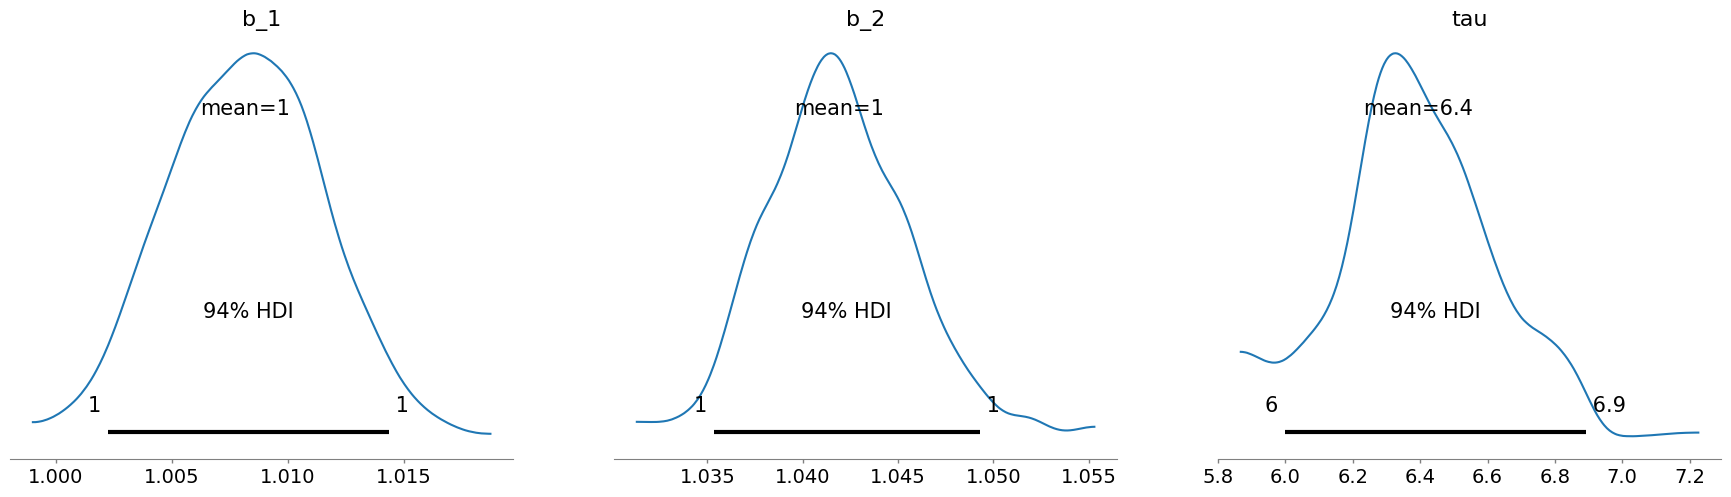

In [63]:
with model:
    az.plot_posterior(
    idata,
    var_names=["b_1", "b_2", "tau"],
    point_estimate="mean",
)

With the gradual switch, we can observe big spread in the switch point, as it starts with 6 and ends at 6.7. Its gradual, so theres so visible line that splits the data, uncertenty in tau is expected.